Olá, Bruno

Meu nome é Ramon. Ao ao longo do texto farei algumas observações sobre melhorias no código. Nas partes em que não houver comentários, está tudo certo, ok? Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser consertado, caso contrário seu projeto **não** será aceito.
</div>

Você pode me responder usando isso:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

###

<div class="alert alert-block alert-success">
<b>Comentário Geral do Revisor</b> <a class="tocSkip"></a>

Obrigado por enviar seu projeto. 
    
Parabéns, você fez um bom trabalho.

Como pontos fortes do projeto, destaco:
- Código simples e eficiente (sem loop desnecessário)
- Uso adequado dos recursos da lição
- O layout da apresentação está excelente. Muito elegante.

Confesso que não entendi os rótulos do eixo X nos gráficos nas páginas 5 e 7. Os nomes me parecem diferentes da base de dados. De qualquer forma, vamos seguir pois você apresentou excelentes notebook e apresentação.

Desejo sucesso na jornada.


</div>




In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Carregar o dataset
df = pd.read_csv('/datasets/rest_data_us_upd.csv')


print(df.info)
print()
print(df.columns)
print()
print(df.head())


<bound method DataFrame.info of          id          object_name                      address  chain  \
0     11786  HABITAT COFFEE SHOP       3708 N EAGLE ROCK BLVD  False   
1     11787             REILLY'S            100 WORLD WAY 120  False   
2     11788       STREET CHURROS      6801 HOLLYWOOD BLVD 253  False   
3     11789    TRINITI ECHO PARK           1814 W SUNSET BLVD  False   
4     11790               POLLEN           2100 ECHO PARK AVE  False   
...     ...                  ...                          ...    ...   
9646  21432      HALL OF JUSTICE             217 W TEMPLE AVE  False   
9647  21433          FIN-MELROSE             5750 MELROSE AVE  False   
9648  21434          JUICY WINGZ          6741 HOLLYWOOD BLVD   True   
9649  21435      MEDIDATE COFFEE      548 S SPRING ST STE 100  False   
9650  21436         CAFE SPROUTS  1300 S SAN PEDRO ST STE 111   True   

     object_type  number  
0           Cafe      26  
1     Restaurant       9  
2      Fast Food      

In [2]:
# Remover duplicatas
df = df.drop_duplicates()

# Padronizar nomes das colunas (minúsculas)
df.columns = df.columns.str.lower()

# Remover linhas sem tipo de estabelecimento
df = df.dropna(subset=['object_type'])

# Padronizar valores do tipo de estabelecimento
df['object_type'] = (
    df['object_type']
    .str.strip()
    .str.lower()
)

#Proporção dos tipos
establishment_counts = (
    df['object_type']
    .value_counts(normalize=True)
    .reset_index()
)

establishment_counts.columns = ['object_type', 'proportion']

print(df.info)
print()
print(df.columns)
print()
print(df.head())

<bound method DataFrame.info of          id          object_name                      address  chain  \
0     11786  HABITAT COFFEE SHOP       3708 N EAGLE ROCK BLVD  False   
1     11787             REILLY'S            100 WORLD WAY 120  False   
2     11788       STREET CHURROS      6801 HOLLYWOOD BLVD 253  False   
3     11789    TRINITI ECHO PARK           1814 W SUNSET BLVD  False   
4     11790               POLLEN           2100 ECHO PARK AVE  False   
...     ...                  ...                          ...    ...   
9646  21432      HALL OF JUSTICE             217 W TEMPLE AVE  False   
9647  21433          FIN-MELROSE             5750 MELROSE AVE  False   
9648  21434          JUICY WINGZ          6741 HOLLYWOOD BLVD   True   
9649  21435      MEDIDATE COFFEE      548 S SPRING ST STE 100  False   
9650  21436         CAFE SPROUTS  1300 S SAN PEDRO ST STE 111   True   

     object_type  number  
0           cafe      26  
1     restaurant       9  
2      fast food      

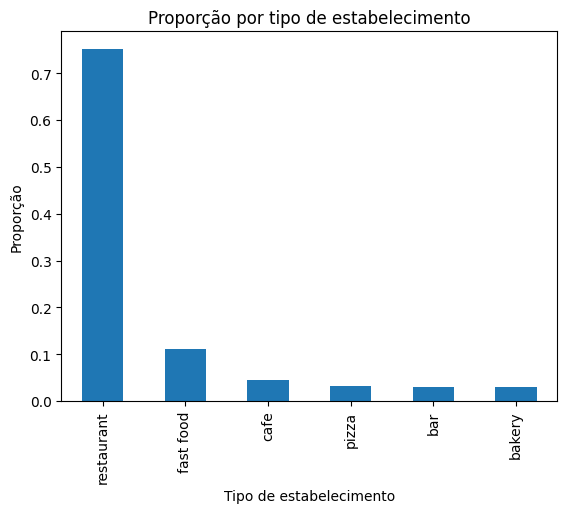

restaurant    0.751736
fast food     0.110455
cafe          0.045073
pizza         0.033157
bar           0.030256
bakery        0.029323
Name: object_type, dtype: float64

In [3]:
# Calcular a proporção de cada tipo de estabelecimento
type_counts = df['object_type'].value_counts(normalize=True)

# Criar o gráfico de barras
plt.figure()
type_counts.plot(kind='bar')
plt.ylabel('Proporção')
plt.xlabel('Tipo de estabelecimento')
plt.title('Proporção por tipo de estabelecimento')
plt.show()

# Exibir as proporções
type_counts



<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Correto. Um gráfico pizza fica mais adequado
</div>

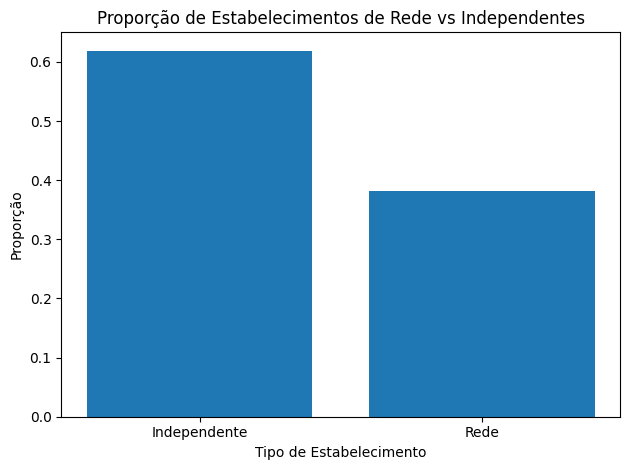

In [4]:
chain_proportions = (
    df['chain']
    .value_counts(normalize=True)
    .reset_index()
)

chain_proportions.columns = ['is_chain', 'proportion']

# Mapear rótulos mais claros
chain_proportions['is_chain'] = chain_proportions['is_chain'].map({
    True: 'Rede',
    False: 'Independente'
})

# =========================
# 4. Gráfico
# =========================

plt.figure()
plt.bar(
    chain_proportions['is_chain'],
    chain_proportions['proportion']
)
plt.title('Proporção de Estabelecimentos de Rede vs Independentes')
plt.ylabel('Proporção')
plt.xlabel('Tipo de Estabelecimento')
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Correto. Um gráfico pizza fica mais adequado
</div>

Qual tipo de estabelecimento é típico para redes?
Geralmente fast foods, mas exitem também pizzarias e restaurantes de rede por exemplo.

O que caracteriza redes: muitos estabelecimentos com um pequeno número de assentos ou poucos estabelecimentos com muitos assentos?

Muitos estabelecimentos com pequeno número de assentos.

  object_type     number
0  restaurant  48.042316
1         bar  44.767123
2   fast food  31.837711
3       pizza  28.459375
4        cafe  25.000000
5      bakery  21.773852


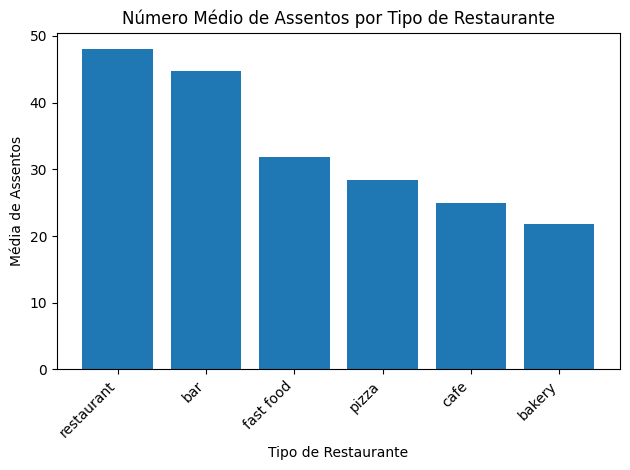

In [5]:
avg_seats = (
    df
    .groupby('object_type')['number']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print(avg_seats)

# =========================
# 4. Gráfico de barras
# =========================

plt.figure()
plt.bar(
    avg_seats['object_type'],
    avg_seats['number']
)
plt.xticks(rotation=45, ha='right')
plt.title('Número Médio de Assentos por Tipo de Restaurante')
plt.ylabel('Média de Assentos')
plt.xlabel('Tipo de Restaurante')
plt.tight_layout()
plt.show()

In [6]:
def extract_street(address):
    # Remove tudo após a vírgula
    street = address.split(',')[0]
    # Remove números
    street = re.sub(r'\d+', '', street)
    # Remove espaços extras
    return street.strip()

df['street_name'] = df['address'].apply(extract_street)

# Visualizar resultado
df[['address', 'street_name']].head()

,address,street_name
0,3708 N EAGLE ROCK BLVD,N EAGLE ROCK BLVD
1,100 WORLD WAY 120,WORLD WAY
2,6801 HOLLYWOOD BLVD 253,HOLLYWOOD BLVD
3,1814 W SUNSET BLVD,W SUNSET BLVD
4,2100 ECHO PARK AVE,ECHO PARK AVE


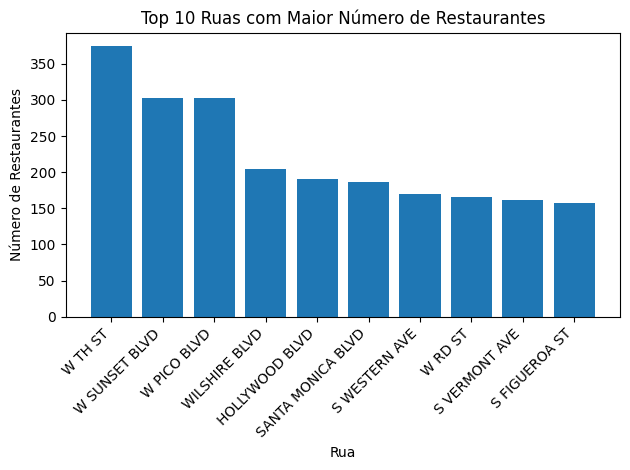

In [7]:
top_10_streets = (
    df['street_name']
    .value_counts()
    .head(10)
    .reset_index()
)

top_10_streets.columns = ['street_name', 'restaurant_count']

# =========================
# 5. Gráfico
# =========================
plt.figure()
plt.bar(
    top_10_streets['street_name'],
    top_10_streets['restaurant_count']
)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Ruas com Maior Número de Restaurantes')
plt.xlabel('Rua')
plt.ylabel('Número de Restaurantes')
plt.tight_layout()
plt.show()

In [8]:
street_counts = df['street_name'].value_counts()

streets_with_one_restaurant = (street_counts == 1).sum()

print(streets_with_one_restaurant)

1161


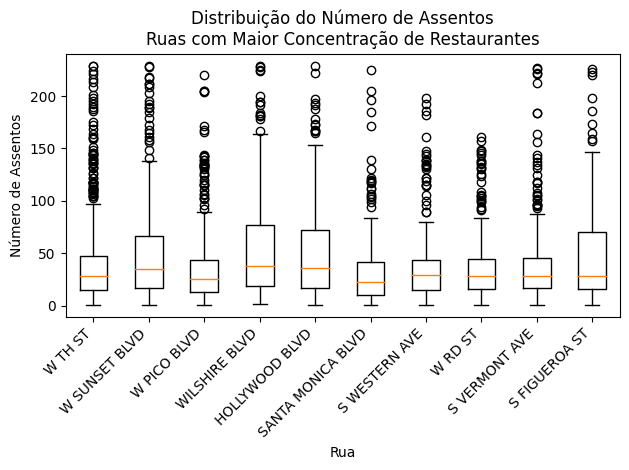

In [9]:
top_streets = (
    df['street_name']
    .value_counts()
    .head(10)
    .index
)

df_top_streets = df[df['street_name'].isin(top_streets)]

# =========================
# 5. Gráfico de distribuição (boxplot)
# =========================
plt.figure()
plt.boxplot(
    [df_top_streets[df_top_streets['street_name'] == street]['number']
     for street in top_streets],
    labels=top_streets,
    vert=True
)
plt.xticks(rotation=45, ha='right')
plt.title('Distribuição do Número de Assentos\nRuas com Maior Concentração de Restaurantes')
plt.ylabel('Número de Assentos')
plt.xlabel('Rua')
plt.tight_layout()
plt.show()

Essas ruas funcionam como polos comerciais, atraindo modelos de negócio diferentes.
Entrada mais fácil para negócios menores e grandes restaurantes ocupam posições estratégicas.
Ruas com muitos restaurantes favorecem diversidade e escala e ruas isoladas tendem a modelos menores e mais conservadores.

CONCLUSÕ GERAL

As ruas com maior concentração de restaurantes apresentam grande variabilidade no número de assentos, indicando a coexistência de estabelecimentos de pequeno e grande porte. Observa-se a presença de outliers com alta capacidade, possivelmente associados a redes ou restaurantes âncora, que se beneficiam do fluxo gerado pelo cluster gastronômico. A mediana inferior à média sugere predominância de restaurantes menores, com poucos estabelecimentos de grande escala puxando a média para cima.

APRESENTAÇÃO

Presentation: <https://drive.google.com/file/d/1wUmSjFVK0V_9v3vnJreQa3V9qdsJAsVh/view?usp=sharing>